In [71]:
import pandas as pd
import numpy as np


df = pd.read_csv("./data/open-meteo-20.98N105.79E12m.csv", skiprows=3)

df = df.drop(columns=['pressure_msl_spread (hPa)'])
df


,time,temperature_2m (°C),relative_humidity_2m (%),rain (mm),precipitation (mm),pressure_msl (hPa),cloud_cover (%),wind_speed_10m (km/h),shortwave_radiation (W/m²),surface_pressure (hPa),wind_direction_10m (°)
0,2000-01-01T00:00,15.3,98,0.0,0.0,1016.2,70,4.6,0.0,1014.8,141
1,2000-01-01T01:00,15.6,99,0.0,0.0,1016.3,98,4.3,0.0,1014.9,132
2,2000-01-01T02:00,15.9,99,0.0,0.0,1015.9,100,4.3,0.0,1014.5,132
3,2000-01-01T03:00,16.3,99,0.0,0.0,1015.5,100,4.7,0.0,1014.1,122
4,2000-01-01T04:00,16.4,99,0.0,0.0,1015.7,100,3.4,0.0,1014.3,108
...,...,...,...,...,...,...,...,...,...,...,...
231499,2026-05-29T19:00,29.4,82,0.0,0.0,1007.6,98,4.5,9.0,1006.2,223
231500,2026-05-29T20:00,28.9,86,0.0,0.0,1008.2,99,2.3,0.0,1006.8,157
231501,2026-05-29T21:00,28.6,88,0.0,0.0,1009.0,98,3.6,0.0,1007.6,177
231502,2026-05-29T22:00,28.4,89,0.0,0.0,1010.1,100,4.5,0.0,1008.7,185


In [72]:
def clean_up_data(real_data):
    clean_data = real_data.copy(deep=True)
    clean_data["time"] = pd.to_datetime(clean_data["time"])

    # Ensure chronological order for rolling windows and shifts to work correctly
    clean_data = clean_data.sort_values("time").reset_index(drop=True)

    # 1. TIME FEATURES (Removed constant 'hour' feature since rows filter strictly for 12:00)
    clean_data["dayofyear"] = clean_data["time"].dt.dayofyear
    clean_data["month"] = clean_data["time"].dt.month
    clean_data["season"] = clean_data["month"].map({
        12: 0, 1: 0, 2: 0,   # winter
        3: 1, 4: 1, 5: 1,    # spring
        6: 2, 7: 2, 8: 2,    # summer
        9: 3, 10: 3, 11: 3   # autumn
    })

    # 2. WIND DIRECTION CIRCULAR ENCODING
    wind_rad = np.deg2rad(clean_data["wind_direction_10m (°)"])
    clean_data["wind_dir_sin"] = np.sin(wind_rad)
    clean_data["wind_dir_cos"] = np.cos(wind_rad)

    # # 3. ROLLING WINDOW FEATURES (Capturing the context of the last 24 hours)
    clean_data["temp_max_24h"] = clean_data["temperature_2m (°C)"].rolling(window=24, min_periods=24).max()
    clean_data["temp_min_24h"] = clean_data["temperature_2m (°C)"].rolling(window=24, min_periods=24).min()
    clean_data["temp_mean_24h"] = clean_data["temperature_2m (°C)"].rolling(window=24, min_periods=24).mean()
    clean_data["total_rain_24h"] = clean_data["rain (mm)"].rolling(window=24, min_periods=24).sum()
    clean_data["humidity_mean_24h"] = clean_data["relative_humidity_2m (%)"].rolling(window=24, min_periods=24).mean()

    # 4. HISTORICAL LAG FEATURES (24 hours ago vs today)
    clean_data["temp_lag_24h"] = clean_data["temperature_2m (°C)"].shift(24)
    clean_data["pressure_lag_24h"] = clean_data["pressure_msl (hPa)"].shift(24)



    # 5. TARGET: Predict temperature 24 hours ahead
    clean_data["target_temp"] = clean_data["temperature_2m (°C)"].shift(-24)

    # Drop rows where rolling windows or shifts created NaN values
    clean_data = clean_data.dropna()

    # 6. FILTER: Keep only the 12:00:00 record from each day
    clean_data = clean_data[clean_data["time"].dt.time == pd.to_datetime("12:00:00").time()].copy()

    return clean_data


def split_train_validation_test(real_data, features):
    # FIX: Run cleaning/rolling transformations on the FULL dataset first 
    # to avoid creating boundary NaN dropouts on New Year's Eve/Day transitions
    clean_df = clean_up_data(real_data)
    
    date = pd.to_datetime(clean_df["time"])

    train_mask = date.dt.year.between(2000, 2023)
    val_mask = date.dt.year == 2024
    test_mask = date.dt.year == 2025

    X_train = clean_df.loc[train_mask, features]
    y_train = clean_df.loc[train_mask, "target_temp"]

    X_val = clean_df.loc[val_mask, features]
    y_val = clean_df.loc[val_mask, "target_temp"]

    X_test = clean_df.loc[test_mask, features]
    y_test = clean_df.loc[test_mask, "target_temp"]

    split_summary = pd.DataFrame({
        "split": ["train", "validation", "test"],
        "years": ["2000-2023", "2024", "2025"],
        "rows": [len(X_train), len(X_val), len(X_test)]
    })

    display(split_summary)

    return X_train, y_train, X_val, y_val, X_test, y_test

In [73]:
features = [
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "cloud_cover (%)",
    "wind_speed_10m (km/h)",
    "pressure_msl (hPa)",
    "rain (mm)",
    "dayofyear",
    "month",
    "season",
    "temp_lag_24h",
    "pressure_lag_24h",
    "wind_dir_sin",
    "wind_dir_cos",
    "temp_max_24h",
    "temp_mean_24h",
    "temp_min_24h",
    "total_rain_24h",
    "humidity_mean_24h",
    "shortwave_radiation (W/m²)"
]

X_train, y_train, X_val, y_val, X_test, y_test = split_train_validation_test(df, features)

,split,years,rows
0,train,2000-2023,8765
1,validation,2024,366
2,test,2025,365


In [74]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import time
from sklearn.linear_model import Ridge



numeric_features = [f for f in features if f != "season"]
categorical_features = ["season"]

preprocessing = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor()

}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model)
    ])

    start_time = time.time()
    pipe.fit(X_train, y_train)
    training_time = time.time() - start_time

    start_time = time.time()
    # FIX: Evaluated predictions on X_val instead of X_test to remove data leakage
    y_pred = pipe.predict(X_val)
    validation_time = time.time() - start_time

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Training Time (s)": training_time,
        "Validation Time (s)": validation_time
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,Model,RMSE,MAE,R2,Training Time (s),Validation Time (s)
4,Gradient Boosting,2.284405,1.784692,0.826186,2.268338,0.003765
1,Ridge Regression,2.333045,1.792859,0.818705,0.011901,0.002208
0,Linear Regression,2.333057,1.792492,0.818704,0.014920,0.002998
3,Random Forest,2.338159,1.831779,0.817910,9.720387,0.017586
5,KNN,2.509954,2.025246,0.790169,0.012271,0.023292
2,Decision Tree,3.506236,2.622131,0.590531,0.136371,0.002679


In [75]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

tscv = TimeSeriesSplit(n_splits=10, gap=1)

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("gradient_boosting", GradientBoostingRegressor(random_state=42)),
])

from scipy.stats import randint, uniform

param_distribs = {
    "gradient_boosting__n_estimators": randint(80, 250),
    "gradient_boosting__learning_rate": uniform(0.03, 0.12),
    "gradient_boosting__max_depth": randint(2, 5),
    "gradient_boosting__min_samples_leaf": randint(1, 15),
    "gradient_boosting__subsample": uniform(0.7, 0.3),
    "gradient_boosting__max_features": [None, "sqrt", 0.7, 1.0],
    "gradient_boosting__min_samples_split": randint(2, 20)
}

rnd_search = RandomizedSearchCV(
    full_pipeline, 
    param_distributions=param_distribs, 
    n_iter=50,
    cv=tscv,
    scoring='neg_root_mean_squared_error', 
    random_state=42,
    n_jobs=-1
)

# FIX: Concatenate 2020-2023 history with 2024 records to maximize optimization history
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

print(f"Combined Training + Validation rows: {len(X_train_full)}")

rnd_search.fit(X_train_full, y_train_full)

Combined Training + Validation rows: 9131


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'gradient_boosting__learning_rate': <scipy.stats....001A4A0A2D130>, 'gradient_boosting__max_depth': <scipy.stats....001A49A6476B0>, 'gradient_boosting__max_features': [None, 'sqrt', ...], 'gradient_boosting__min_samples_leaf': <scipy.stats....001A49A647CF0>, ...}"
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [76]:
tuned_model = rnd_search.best_estimator_

# Train
train_pred = tuned_model.predict(X_train)

# Validation
val_pred = tuned_model.predict(X_val)

# Test
test_pred = tuned_model.predict(X_test)

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

train_mae, train_rmse, train_r2 = evaluate(y_train, train_pred)
val_mae, val_rmse, val_r2 = evaluate(y_val, val_pred)
test_mae, test_rmse, test_r2 = evaluate(y_test, test_pred)

print(f"Train RMSE: {train_rmse:.3f}, R²: {train_r2:.3f}")
print(f"Val   RMSE: {val_rmse:.3f}, R²: {val_r2:.3f}")
print(f"Test  RMSE: {test_rmse:.3f}, R²: {test_r2:.3f}")

Train RMSE: 2.050, R²: 0.871
Val   RMSE: 2.041, R²: 0.861
Test  RMSE: 2.191, R²: 0.830


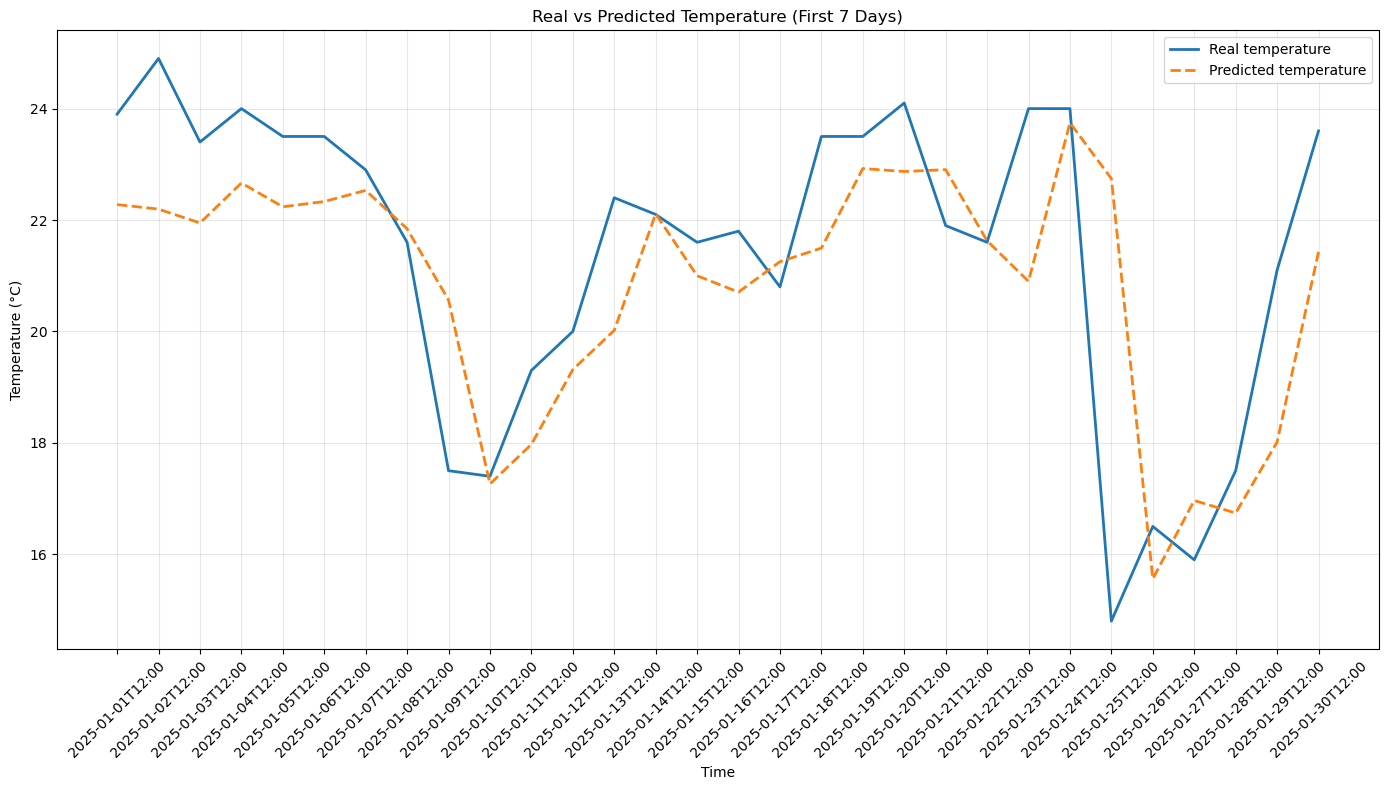

In [77]:
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    "time": df.loc[y_test.index, "time"],
    "real_temperature": y_test.values,
    "predicted_temperature": tuned_pred,
})

# FIX: Slice exactly at head(7) to properly match the weekly comment window
plot_df = comparison_df.head(30)

plt.figure(figsize=(14, 8))
plt.plot(plot_df["time"], plot_df["real_temperature"], label="Real temperature", linewidth=2)
plt.plot(plot_df["time"], plot_df["predicted_temperature"], label="Predicted temperature", linewidth=2, linestyle="--")
plt.title("Real vs Predicted Temperature (First 7 Days)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
importances = tuned_model.named_steps["gradient_boosting"].feature_importances_
feature_names = tuned_model.named_steps["preprocessing"].get_feature_names_out()
feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df

,feature,importance
0,temperature_2m (°C),0.727352
13,temp_mean_24h,0.095668
14,temp_min_24h,0.051280
6,dayofyear,0.019301
4,pressure_msl (hPa),0.018058
12,temp_max_24h,0.016428
18,season_0,0.014587
11,wind_dir_cos,0.013171
3,wind_speed_10m (km/h),0.007474
9,pressure_lag_24h,0.006728


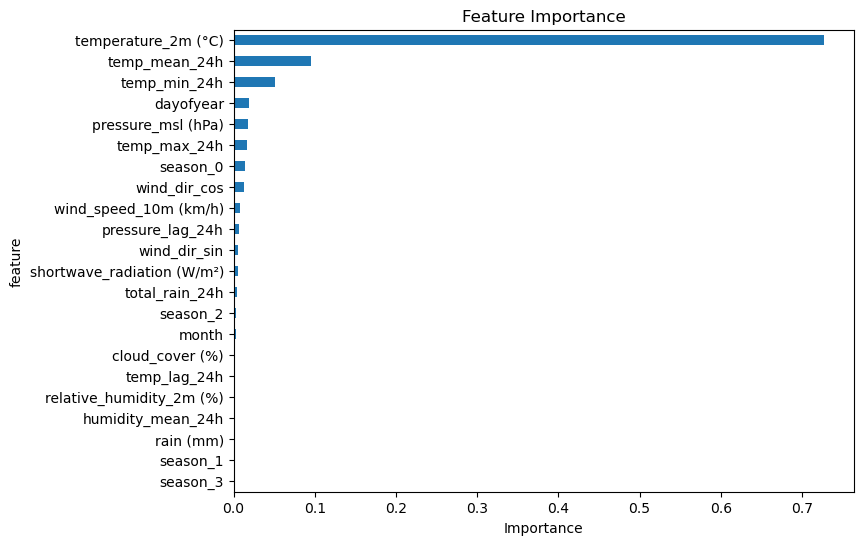

In [79]:
feature_importance_df.plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8, 6),
    legend=False
)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [80]:
from joblib import dump

# Export your robustly trained model file
dump(tuned_model, 'temperature_prediction_model.pkl')

['temperature_prediction_model.pkl']